# Analysis on the acquirer factilitaror market data from BCRP

In [3]:
import sys
from functools import reduce

import numpy as np
import pandas as pd
import requests

sys.path.append("..")
sys.path.append("../..")
import catppuccin
import matplotlib.pyplot as plt

from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# TODO: create a visualization.py
plt.style.use("mocha")

In [3]:
# dir(pd)
# help(pd.DataFrame.head)
# dir(list)
# help(zip)

****

# **Get cleaned data**



## **Pagos inmediatos con alias (Valor y Número en Millones de Soles)**

In [ ]:
codes_names_pagos_inmediatos = {
    "PN42661EM": "valor_transferencias_intrabancarias",
    "PN42662EM": "valor_transferencias_intrabancarias_yape",
    "PN42663EM": "valor_transferencias_intrabancarias_plin",
    "PN42664EM": "valor_transferencias_intrabancarias_otras_billeteras",
    "PN42665EM": "valor_transferencias_interbancarias",
    "PN42666EM": "valor_transferencias_interbancarias_visadirect",
    "PN42667EM": "valor_transferencias_interbancarias_visadirect_yape",
    "PN42668EM": "valor_transferencias_interbancarias_visadirect_plin",
    "PN42669EM": "valor_transferencias_interbancarias_visadirect_otras_billeteras",
    "PN42670EM": "valor_transferencias_interbancarias_cce",
    "PN42671EM": "numero_transferencias_intrabancarias",
    "PN42672EM": "numero_transferencias_intrabancarias_yape",
    "PN42673EM": "numero_transferencias_intrabancarias_plin",
    "PN42674EM": "numero_transferencias_intrabancarias_otras_billeteras",
    "PN42675EM": "numero_transferencias_interbancarias",
    "PN42676EM": "numero_transferencias_interbancarias_visadirect",
    "PN42677EM": "numero_transferencias_interbancarias_visadirect_yape",
    "PN42678EM": "numero_transferencias_interbancarias_visadirect_plin",
    "PN42679EM": "numero_transferencias_interbancarias_visadirect_otras_billeteras",
    "PN42680EM": "numero_transferencias_interbancarias_cce",
}

In [ ]:
df_pagos_inmediatos = build_bcrp_dataset(codes_names_pagos_inmediatos)
df_pagos_inmediatos.head()

,period,valor_transferencias_intrabancarias,valor_transferencias_intrabancarias_yape,valor_transferencias_intrabancarias_plin,valor_transferencias_intrabancarias_otras_billeteras,valor_transferencias_interbancarias,valor_transferencias_interbancarias_visadirect,valor_transferencias_interbancarias_visadirect_yape,valor_transferencias_interbancarias_visadirect_plin,valor_transferencias_interbancarias_visadirect_otras_billeteras,valor_transferencias_interbancarias_cce,numero_transferencias_intrabancarias,numero_transferencias_intrabancarias_yape,numero_transferencias_intrabancarias_plin,numero_transferencias_intrabancarias_otras_billeteras,numero_transferencias_interbancarias,numero_transferencias_interbancarias_visadirect,numero_transferencias_interbancarias_visadirect_yape,numero_transferencias_interbancarias_visadirect_plin,numero_transferencias_interbancarias_visadirect_otras_billeteras,numero_transferencias_interbancarias_cce
0,2026-03-01,"37,017.29","36,234.11",763.06,20.12,"17,005.37","12,532.04","4,866.50","7,449.27",216.27,"4,473.33",944.66,935.14,9.25,0.27,229.34,193.64,69.52,120.63,3.49,35.69
1,2026-02-01,"32,705.43","31,999.32",688.34,17.76,"15,267.94","11,122.98","3,989.35","6,942.07",191.56,"4,144.95",823.36,814.84,8.27,0.24,204.38,170.70,56.67,110.91,3.12,33.68
2,2026-01-01,"33,903.98","33,162.59",720.25,21.13,"15,604.10","11,571.87","4,246.93","7,099.60",225.34,"4,032.22",844.52,835.65,8.58,0.29,208.13,175.54,59.38,112.58,3.59,32.59
3,2025-12-01,"38,834.87","37,937.65",872.18,25.04,"18,264.34","13,877.13","5,066.26","8,546.57",264.30,"4,387.21",923.65,913.49,9.84,0.32,232.10,198.09,67.98,126.10,4.00,34.02
4,2025-11-01,"33,171.81","32,418.60",731.72,21.48,"15,378.07","11,555.41","4,197.39","7,133.36",224.66,"3,822.66",851.54,842.33,8.91,0.30,209.67,177.48,60.15,113.62,3.70,32.19


## **Monto y número de operaciones procesadas por los adquirentes y facilitadores de pago por segmento de comercio (millones de soles y miles de operaciones)**

In [57]:
codes_names = {
    "PN42681EM": "monto_segmentos_minoristas",
    "PN42682EM": "monto_segmentos_minoristas_farmacias",
    "PN42683EM": "monto_segmentos_minoristas_gasolineras",
    "PN42684EM": "monto_segmentos_minoristas_microcomercios",
    "PN42685EM": "monto_segmentos_minoristas_restaurantes",
    "PN42686EM": "monto_segmentos_minoristas_supermercados",
    "PN42687EM": "monto_segmentos_minoristas_transportes",
    "PN42688EM": "monto_otros_segmentos",
    "PN42689EM": "monto_total",
    # instrumentos de pago de alto y bajo valor
    "PN42156EM": "alto_valor",
    "PN42160EM": "bajo_valor",
    "PN42164EM": "bajo_valor_tarjetas_pago",
    "PN42165EM": "bajo_valor_tarjetas_debito",
    "PN42168EM": "bajo_valor_tarjetas_credito",
    # instrumentos de pago y alto valor en moneda nacional
    "PN42995EM": "bajo_valor_mn",
    "PN42999EM": "bajo_valor_tarjetas_pago_mn",
    # Pagos inmediatos con alias
    "PN42661EM": "pagos_inmd_valor_transf_intrab",
    "PN42665EM": "pagos_imd_valor_transf_interb",
    # "PN42690EM": "numero_segmentos_minoristas",
    # "PN42691EM": "numero_segmentos_minoristas_farmacias",
    # "PN42692EM": "numero_segmentos_minoristas_gasolineras",
    # "PN42693EM": "numero_segmentos_minoristas_microcomercios",
    # "PN42694EM": "numero_segmentos_minoristas_restaurantes",
    # "PN42695EM": "numero_segmentos_minoristas_supermercados",
    # "PN42696EM": "numero_segmentos_minoristas_transportes",
    # "PN42697EM": "numero_otros_segmentos",
    # "PN42698EM": "numero_total",
    "PN43373EM": "mn_monto_segmentos_minoristas",
    # "PN43374EM": "mn_monto_segmentos_minoristas_farmacias",
    # "PN43375EM": "mn_monto_segmentos_minoristas_gasolineras",
    # "PN43376EM": "mn_monto_segmentos_minoristas_microcomercios",
    # "PN43377EM": "mn_monto_segmentos_minoristas_restaurantes",
    # "PN43378EM": "mn_monto_segmentos_minoristas_supermercados",
    # "PN43379EM": "mn_monto_segmentos_minoristas_transportes",
    "PN43380EM": "mn_monto_otros_segmentos",
    "PN43381EM": "mn_monto_total",
    # "PN43382EM": "mn_numero_segmentos_minoristas",
    # "PN43383EM": "mn_numero_segmentos_minoristas_farmacias",
    # "PN43384EM": "mn_numero_segmentos_minoristas_gasolineras",
    # "PN43385EM": "mn_numero_segmentos_minoristas_microcomercios",
    # "PN43386EM": "mn_numero_segmentos_minoristas_restaurantes",
    # "PN43387EM": "mn_numero_segmentos_minoristas_supermercados",
    # "PN43388EM": "mn_numero_segmentos_minoristas_transportes",
    # "PN43389EM": "mn_numero_otros_segmentos",
    # "PN43390EM": "mn_numero_total",
    # "PN43391EM": "me_monto_segmentos_minoristas",
    # "PN43392EM": "me_monto_segmentos_minoristas_farmacias",
    # "PN43393EM": "me_monto_segmentos_minoristas_gasolineras",
    # "PN43394EM": "me_monto_segmentos_minoristas_microcomercios",
    # "PN43395EM": "me_monto_segmentos_minoristas_restaurantes",
    # "PN43396EM": "me_monto_segmentos_minoristas_supermercados",
    # "PN43397EM": "me_monto_segmentos_minoristas_transportes",
    # "PN43398EM": "me_monto_otros_segmentos",
    # "PN43399EM": "me_monto_total",
    # "PN43400EM": "me_numero_segmentos_minoristas",
    # "PN43401EM": "me_numero_segmentos_minoristas_farmacias",
    # "PN43402EM": "me_numero_segmentos_minoristas_gasolineras",
    # "PN43403EM": "me_numero_segmentos_minoristas_microcomercios",
    # "PN43404EM": "me_numero_segmentos_minoristas_restaurantes",
    # "PN43405EM": "me_numero_segmentos_minoristas_supermercados",
    # "PN43406EM": "me_numero_segmentos_minoristas_transportes",
    # "PN43407EM": "me_numero_otros_segmentos",
    # "PN43408EM": "me_numero_total",
}

In [58]:
df_acq_fac_market = build_bcrp_dataset(codes_names)

In [59]:
df_acq_fac_market.head()

,period,monto_segmentos_minoristas,monto_segmentos_minoristas_farmacias,monto_segmentos_minoristas_gasolineras,monto_segmentos_minoristas_microcomercios,monto_segmentos_minoristas_restaurantes,monto_segmentos_minoristas_supermercados,monto_segmentos_minoristas_transportes,monto_otros_segmentos,monto_total,alto_valor,bajo_valor,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_credito,bajo_valor_mn,bajo_valor_tarjetas_pago_mn,pagos_inmd_valor_transf_intrab,pagos_imd_valor_transf_interb,mn_monto_segmentos_minoristas,mn_monto_otros_segmentos,mn_monto_total
0,2026-03-01,"5,096.93",463.42,"1,143.50",767.02,"1,039.92","1,501.64",181.43,"8,071.04","13,167.96","478,458.55","417,155.45","19,878.20","9,287.07","10,591.13","325,727.44","17,222.43","37,017.29","17,005.37","5,086.16","7,325.44","12,411.59"
1,2026-02-01,"4,396.24",405.50,804.62,730.87,"1,001.50","1,281.78",171.95,"7,300.84","11,697.08","411,779.84","377,297.19","17,366.34","8,126.11","9,240.23","299,851.62","14,978.76","32,705.43","15,267.94","4,387.52","6,629.87","11,017.39"
2,2026-01-01,"4,546.09",442.27,842.99,770.67,"1,037.22","1,313.98",138.96,"7,705.93","12,252.01","398,930.84","394,384.29","18,073.66","8,557.64","9,516.03","304,647.08","15,450.02","33,903.98","15,604.10","4,536.81","6,948.81","11,485.61"
3,2025-12-01,"5,323.27",431.18,884.24,886.44,"1,163.75","1,831.17",126.48,"9,603.78","14,927.05","462,444.46","458,953.59","20,981.01","10,085.39","10,895.62","359,087.44","18,499.77","38,834.87","18,264.34","5,313.00","8,951.74","14,264.74"
4,2025-11-01,"4,413.19",407.30,828.91,750.96,989.34,"1,328.39",108.29,"7,787.04","12,200.23","398,541.09","374,481.11","17,752.58","7,940.23","9,812.35","287,236.06","15,203.30","33,171.81","15,378.07","4,403.04","7,039.23","11,442.28"


In [60]:
df_acq_fac_market.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   period                                     60 non-null     datetime64[us]
 1   monto_segmentos_minoristas                 27 non-null     float64       
 2   monto_segmentos_minoristas_farmacias       27 non-null     float64       
 3   monto_segmentos_minoristas_gasolineras     27 non-null     float64       
 4   monto_segmentos_minoristas_microcomercios  27 non-null     float64       
 5   monto_segmentos_minoristas_restaurantes    27 non-null     float64       
 6   monto_segmentos_minoristas_supermercados   27 non-null     float64       
 7   monto_segmentos_minoristas_transportes     27 non-null     float64       
 8   monto_otros_segmentos                      27 non-null     float64       
 9   monto_total                       

# **Analysis**

In [49]:
df_acq_fac_market.tail()

,period,monto_segmentos_minoristas,monto_segmentos_minoristas_farmacias,monto_segmentos_minoristas_gasolineras,monto_segmentos_minoristas_microcomercios,monto_segmentos_minoristas_restaurantes,monto_segmentos_minoristas_supermercados,monto_segmentos_minoristas_transportes,monto_otros_segmentos,monto_total,alto_valor,bajo_valor,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_credito,bajo_valor_mn,bajo_valor_tarjetas_pago_mn,pagos_inmd_valor_transf_intrab,pagos_imd_valor_transf_interb
55,2021-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"394,719.02","297,936.89","9,663.66","4,407.76","5,255.90",NaN,NaN,NaN,NaN
56,2021-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"337,876.32","295,334.15","9,876.88","4,457.31","5,419.56",NaN,NaN,NaN,NaN
57,2021-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"313,898.09","274,454.77","8,238.80","3,485.09","4,753.71",NaN,NaN,NaN,NaN
58,2021-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"360,985.99","274,040.36","8,690.21","3,721.74","4,968.47",NaN,NaN,NaN,NaN
59,2021-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"280,547.01","259,622.61","7,608.25","3,161.06","4,447.19",NaN,NaN,NaN,NaN


In [51]:
# comparing MN vs TOTAL (including ME)
df_compare = (
    df_acq_fac_market[
        [
            "period",
            "bajo_valor",
            "bajo_valor_mn",
            "bajo_valor_tarjetas_pago",
            "bajo_valor_tarjetas_pago_mn",
        ]
    ]
    .dropna()
    .copy()
)

df_compare["bajo_valor_me"] = df_compare["bajo_valor"] - df_compare["bajo_valor_mn"]

df_compare["tarjetas_pago_me"] = (
    df_compare["bajo_valor_tarjetas_pago"] - df_compare["bajo_valor_tarjetas_pago_mn"]
)

df_compare["share_me_bajo_valor"] = (
    df_compare["bajo_valor_me"] / df_compare["bajo_valor"]
)

df_compare["share_me_tarjetas"] = (
    df_compare["tarjetas_pago_me"] / df_compare["bajo_valor_tarjetas_pago"]
)

df_compare.head()

,period,bajo_valor,bajo_valor_mn,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_pago_mn,bajo_valor_me,tarjetas_pago_me,share_me_bajo_valor,share_me_tarjetas
0,2026-03-01,"417,155.45","325,727.44","19,878.20","17,222.43","91,428.00","2,655.76",0.22,0.13
1,2026-02-01,"377,297.19","299,851.62","17,366.34","14,978.76","77,445.58","2,387.58",0.21,0.14
2,2026-01-01,"394,384.29","304,647.08","18,073.66","15,450.02","89,737.21","2,623.64",0.23,0.15
3,2025-12-01,"458,953.59","359,087.44","20,981.01","18,499.77","99,866.15","2,481.24",0.22,0.12
4,2025-11-01,"374,481.11","287,236.06","17,752.58","15,203.30","87,245.06","2,549.28",0.23,0.14


In [62]:
df_compare = (
    df_acq_fac_market[
        [
            "period",
            "monto_total",
            "mn_monto_total",
            "monto_segmentos_minoristas",
            "mn_monto_segmentos_minoristas",
            "monto_otros_segmentos",
            "mn_monto_otros_segmentos",
        ]
    ]
    .dropna()
    .copy()
)

df_compare["me_monto_total"] = df_compare["monto_total"] - df_compare["mn_monto_total"]

df_compare["me_monto_segmentos_minoristas"] = (
    df_compare["monto_segmentos_minoristas"]
    - df_compare["mn_monto_segmentos_minoristas"]
)

df_compare["me_monto_otros_segmentos"] = (
    df_compare["monto_otros_segmentos"] - df_compare["mn_monto_otros_segmentos"]
)

df_compare["share_me_monto_total"] = (
    df_compare["me_monto_total"] / df_compare["monto_total"]
)

df_compare["share_me_minoristas"] = (
    df_compare["me_monto_segmentos_minoristas"]
    / df_compare["monto_segmentos_minoristas"]
)

df_compare["share_me_otros"] = (
    df_compare["me_monto_otros_segmentos"] / df_compare["monto_otros_segmentos"]
)

df_compare.head()

,period,monto_total,mn_monto_total,monto_segmentos_minoristas,mn_monto_segmentos_minoristas,monto_otros_segmentos,mn_monto_otros_segmentos,me_monto_total,me_monto_segmentos_minoristas,me_monto_otros_segmentos,share_me_monto_total,share_me_minoristas,share_me_otros
0,2026-03-01,"13,167.96","12,411.59","5,096.93","5,086.16","8,071.04","7,325.44",756.37,10.77,745.60,0.06,0.00,0.09
1,2026-02-01,"11,697.08","11,017.39","4,396.24","4,387.52","7,300.84","6,629.87",679.69,8.72,670.97,0.06,0.00,0.09
2,2026-01-01,"12,252.01","11,485.61","4,546.09","4,536.81","7,705.93","6,948.81",766.40,9.28,757.12,0.06,0.00,0.10
3,2025-12-01,"14,927.05","14,264.74","5,323.27","5,313.00","9,603.78","8,951.74",662.31,10.27,652.04,0.04,0.00,0.07
4,2025-11-01,"12,200.23","11,442.28","4,413.19","4,403.04","7,787.04","7,039.23",757.96,10.15,747.81,0.06,0.00,0.10


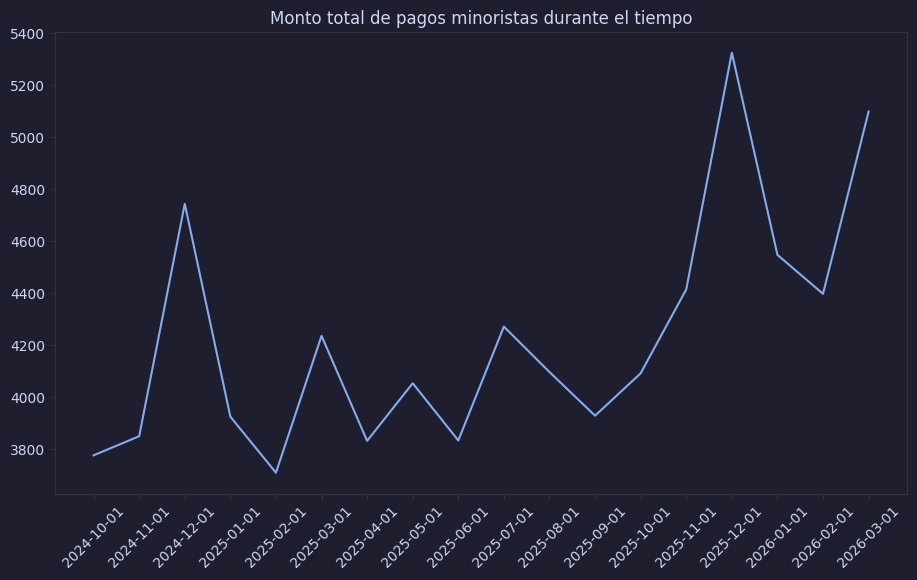

In [ ]:
# reatil payments thorugh time
df_plot = (
    df_acq_fac_market[["period", "monto_segmentos_minoristas"]]
    .query("period >= '2024-10-01'")
    .copy()
)

df_plot = df_plot.sort_values("period")

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df_plot["period"].astype(str), df_plot["monto_segmentos_minoristas"], alpha=0.95
)
ax.set_title("Monto total de pagos minoristas durante el tiempo")

plt.xticks(rotation=45)

plt.show()

In [14]:
df_acq_fac_market.tail()

,period,monto_segmentos_minoristas,monto_segmentos_minoristas_farmacias,monto_segmentos_minoristas_gasolineras,monto_segmentos_minoristas_microcomercios,monto_segmentos_minoristas_restaurantes,monto_segmentos_minoristas_supermercados,monto_segmentos_minoristas_transportes,monto_otros_segmentos,monto_total,numero_segmentos_minoristas,numero_segmentos_minoristas_farmacias,numero_segmentos_minoristas_gasolineras,numero_segmentos_minoristas_microcomercios,numero_segmentos_minoristas_restaurantes,numero_segmentos_minoristas_supermercados,numero_segmentos_minoristas_transportes,numero_otros_segmentos,numero_total
22,2024-05-01,"3,903.19",341.68,723.73,730.89,917.27,"1,111.48",78.14,"5,812.13","9,715.32","69,182.51","6,413.15","10,697.84","16,441.64","16,966.80","16,550.95","2,112.13","49,597.36","118,779.88"
23,2024-04-01,"3,545.25",315.60,681.35,653.81,795.08,"1,028.89",70.52,"5,341.42","8,886.67","63,345.77","5,748.79","9,941.87","14,890.37","15,518.42","15,254.51","1,991.82","45,291.43","108,637.20"
24,2024-03-01,"3,934.83",320.03,689.11,726.85,912.46,"1,197.17",89.21,"5,539.98","9,474.81","66,817.09","5,855.47","9,875.34","15,823.14","15,993.60","16,715.55","2,554.00","44,598.75","111,415.83"
25,2024-02-01,"3,386.22",297.86,629.45,381.87,930.79,"1,037.10",109.14,"5,375.74","8,761.96","59,288.72","5,248.95","8,836.69","11,404.76","16,075.98","15,148.00","2,574.34","42,367.05","101,655.77"
26,2024-01-01,"3,705.97",312.92,640.36,697.00,900.41,"1,028.11",127.17,"5,167.67","8,873.63","60,856.19","5,469.93","8,777.13","14,126.40","15,077.23","14,469.75","2,935.75","40,726.82","101,583.02"


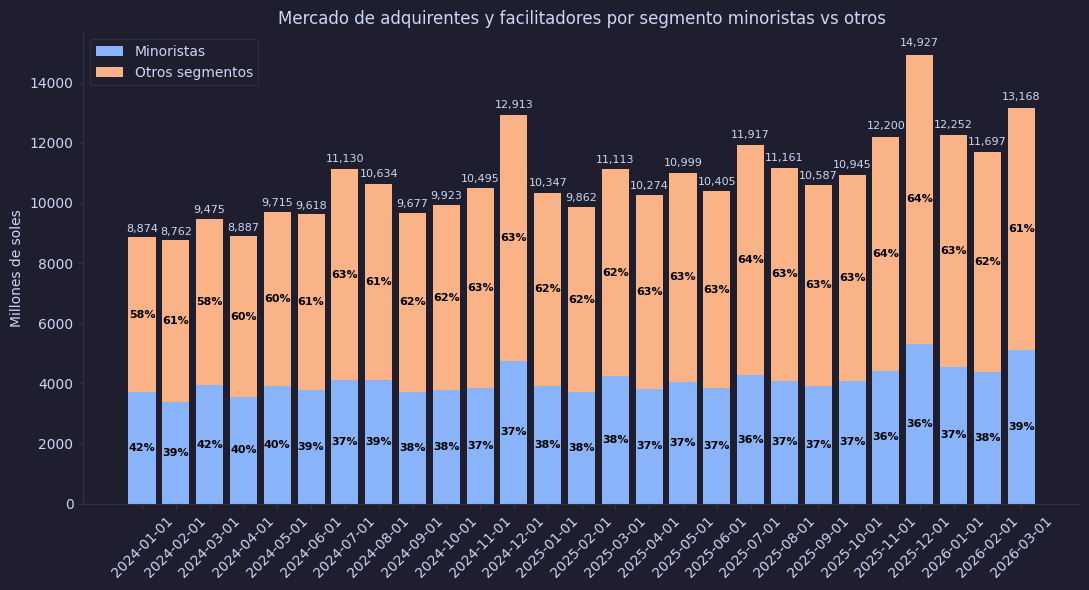

In [ ]:
df_plot = df_acq_fac_market[
    ["period", "monto_segmentos_minoristas", "monto_otros_segmentos"]
].sort_values("period")

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    df_plot["period"].astype(str),
    df_plot["monto_segmentos_minoristas"],
    label="Minoristas",
)

ax.bar(
    df_plot["period"].astype(str),
    df_plot["monto_otros_segmentos"],
    bottom=df_plot["monto_segmentos_minoristas"],
    label="Otros segmentos",
)

for i, row in df_plot.reset_index().iterrows():

    total = row["monto_segmentos_minoristas"] + row["monto_otros_segmentos"]
    pct_minoristas = row["monto_segmentos_minoristas"] / total
    pct_otros = row["monto_otros_segmentos"] / total

    ax.text(
        i,
        row["monto_segmentos_minoristas"] / 2,
        f"{pct_minoristas:.0%}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="black",
    )

    ax.text(
        i,
        row["monto_segmentos_minoristas"] + row["monto_otros_segmentos"] / 2,
        f"{pct_otros:.0%}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="black",
    )

    ax.text(
        i,
        total * 1.02,
        f"{total:,.0f}",
        ha="center",
        fontsize=8,
    )

ax.set_title("Mercado de adquirentes y facilitadores por segmento minoristas vs otros")
ax.set_ylabel("Millones de soles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

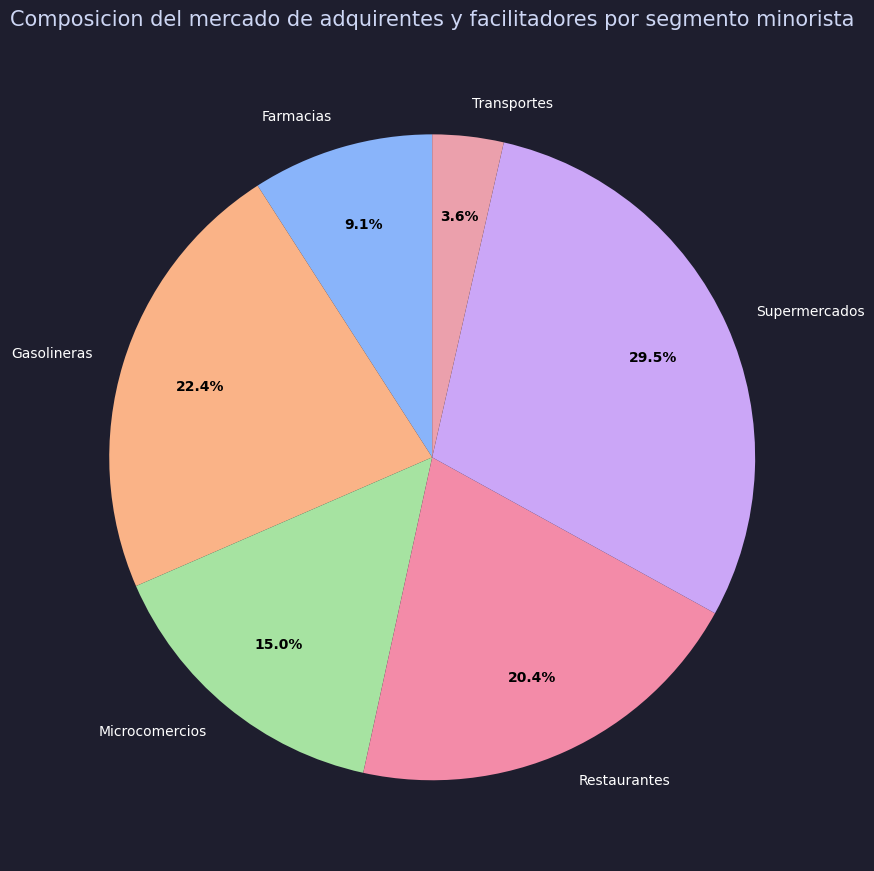

In [ ]:
# composicion del mercado de adquirentes y facilitadores pagos minoristas
df_pie = df_acq_fac_market[df_acq_fac_market["period"] == "2026-03-01"]

labels = [
    "Farmacias",
    "Gasolineras",
    "Microcomercios",
    "Restaurantes",
    "Supermercados",
    "Transportes",
    # "Otros segmentos",
]

values = [
    df_pie["monto_segmentos_minoristas_farmacias"].values[0],
    df_pie["monto_segmentos_minoristas_gasolineras"].values[0],
    df_pie["monto_segmentos_minoristas_microcomercios"].values[0],
    df_pie["monto_segmentos_minoristas_restaurantes"].values[0],
    df_pie["monto_segmentos_minoristas_supermercados"].values[0],
    df_pie["monto_segmentos_minoristas_transportes"].values[0],
    # df_pie["monto_otros_segmentos"].values[0],
]

fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 10, "color": "white"},
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")
    autotext.set_color("black")

ax.set_title(
    "Composicion del mercado de adquirentes y facilitadores por segmento minorista",
    fontsize=15,
    pad=20,
)

plt.tight_layout()
plt.show()

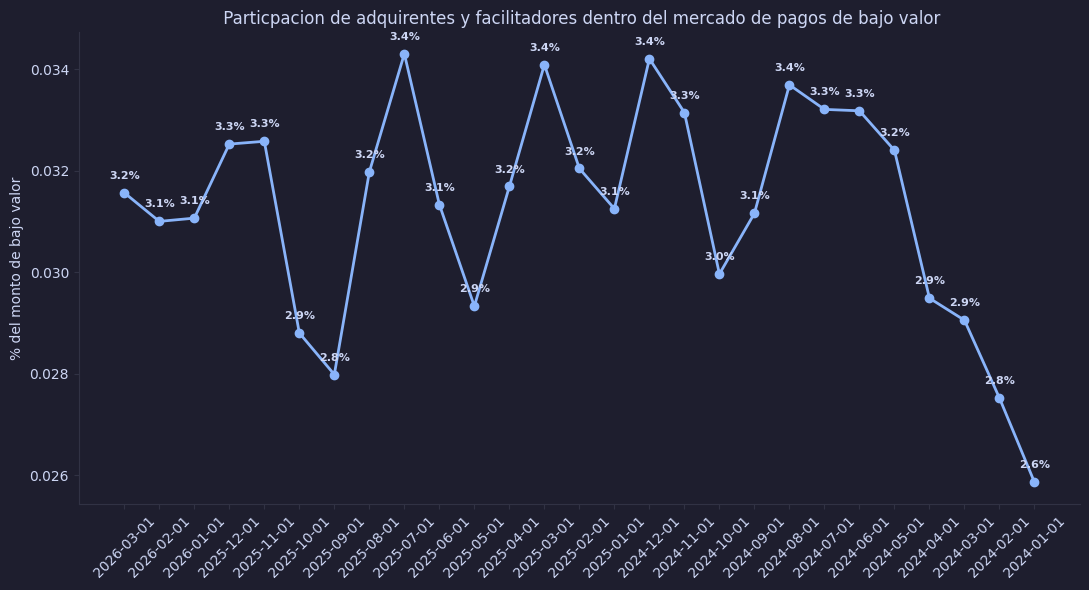

In [42]:
# que % del mercado total de pagos de bajo valor es procesado por adquirentes y facilitadores
df_plot = df_acq_fac_market[["period", "monto_total", "bajo_valor"]].dropna().copy()

df_plot["share_adq_fac"] = df_plot["monto_total"] / df_plot["bajo_valor"]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df_plot["period"].astype(str),
    df_plot["share_adq_fac"],
    marker="o",
    linewidth=2,
)

for i, row in df_plot.reset_index().iterrows():

    ax.annotate(
        f"{row['share_adq_fac']:.1%}",
        (i, row["share_adq_fac"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

plt.xticks(rotation=45)

ax.set_title(
    " Particpacion de adquirentes y facilitadores dentro del mercado de pagos de bajo valor"
)
ax.set_ylabel("% del monto de bajo valor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

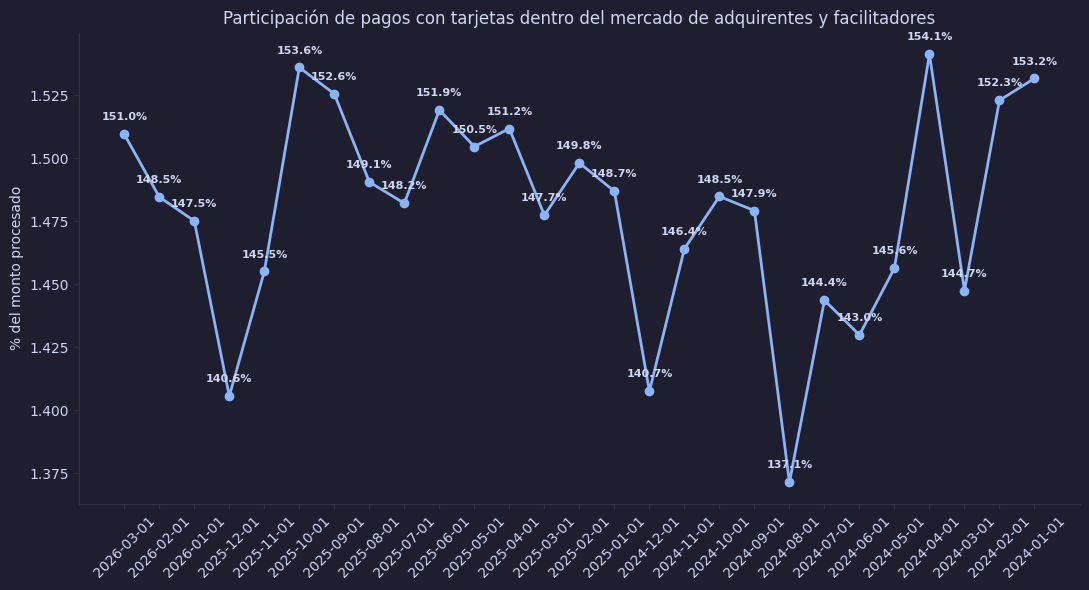

In [43]:
df_plot = (
    df_acq_fac_market[["period", "monto_total", "bajo_valor_tarjetas_pago"]]
    .dropna()
    .copy()
)

df_plot["share_tarjetas"] = df_plot["bajo_valor_tarjetas_pago"] / df_plot["monto_total"]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df_plot["period"].astype(str),
    df_plot["share_tarjetas"],
    marker="o",
    linewidth=2,
)

for i, row in df_plot.reset_index().iterrows():

    ax.annotate(
        f"{row['share_tarjetas']:.1%}",
        (i, row["share_tarjetas"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

plt.xticks(rotation=45)

ax.set_title(
    "Participación de pagos con tarjetas dentro del mercado de adquirentes y facilitadores"
)

ax.set_ylabel("% del monto procesado")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

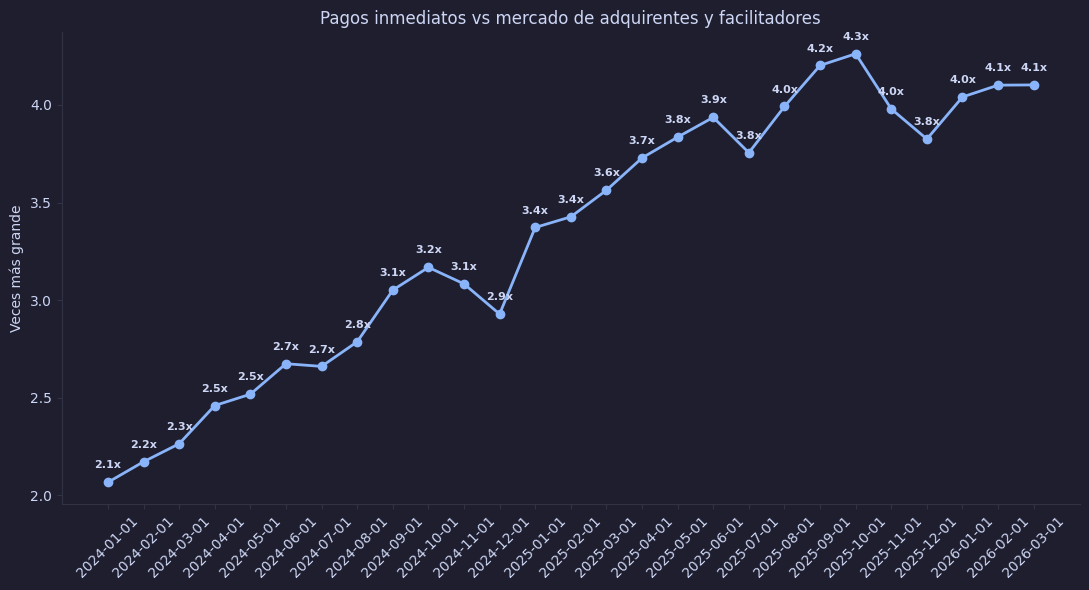

In [ ]:
# size of the immediate-payment ecosystem relative to merchant-acquiring commerce
# carefull: these series may overlap since acq + fac market has inside immediate payments
df_plot = (
    df_acq_fac_market[
        [
            "period",
            "monto_total",
            "pagos_inmd_valor_transf_intrab",
            "pagos_imd_valor_transf_interb",
        ]
    ]
    .dropna()
    .copy()
    .sort_values("period")
)

df_plot["wallet_total"] = (
    df_plot["pagos_inmd_valor_transf_intrab"] + df_plot["pagos_imd_valor_transf_interb"]
)

df_plot["wallet_vs_acq_fac"] = df_plot["wallet_total"] / df_plot["monto_total"]


fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df_plot["period"].astype(str),
    df_plot["wallet_vs_acq_fac"],
    marker="o",
    linewidth=2,
)

for i, row in df_plot.reset_index().iterrows():

    ax.annotate(
        f"{row['wallet_vs_acq_fac']:.1f}x",
        (i, row["wallet_vs_acq_fac"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

plt.xticks(rotation=45)
ax.set_title("Pagos inmediatos vs mercado de adquirentes y facilitadores")
ax.set_ylabel("Veces más grande")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## MCC Categories Likely Included in "Otros Segmentos"

According to the BCRP interoperability and MCC documentation, the following categories are likely aggregated inside `otros_segmentos`:

- Aerolíneas
- Alojamientos
- Educación
- Electrodomésticos
- Salud
- Servicios personales
- Telecomunicaciones
- Tiendas por departamento
- Otros comercios
- Otros:
  - veterinarias
  - instalación de aire acondicionado
  - trabajos eléctricos
  - albañilería
  - campos deportivos y recreacionales
  - lavanderías
  - tintorerías
  - desinfección
  - among others

### Explicitly Excluded Categories

The following MCC-related segments are explicitly excluded by the BCRP methodology:

- Entidades financieras
- Gobierno
- Servicios públicos
